SPDC BELL SOURCE VALIDATION

Simulating 50 mW pump power...
Pair 0: lambda_signal=805.418 nm, lambda_idler=811.404 nm, Δlambda=-5.986 nm
Pair 1: lambda_signal=803.520 nm, lambda_idler=813.340 nm, Δlambda=-9.820 nm
Pair 2: lambda_signal=804.131 nm, lambda_idler=812.714 nm, Δlambda=-8.583 nm
Pair 3: lambda_signal=803.659 nm, lambda_idler=813.197 nm, Δlambda=-9.538 nm
Pair 4: lambda_signal=799.901 nm, lambda_idler=817.081 nm, Δlambda=-17.180 nm
Pair 5: lambda_signal=803.175 nm, lambda_idler=813.694 nm, Δlambda=-10.519 nm
Pair 6: lambda_signal=805.817 nm, lambda_idler=811.000 nm, Δlambda=-5.183 nm
Pair 7: lambda_signal=805.167 nm, lambda_idler=811.660 nm, Δlambda=-6.493 nm
Pair 8: lambda_signal=801.858 nm, lambda_idler=815.049 nm, Δlambda=-13.191 nm
Pair 9: lambda_signal=804.249 nm, lambda_idler=812.594 nm, Δlambda=-8.345 nm
  Emitted 10149 photon pairs

Simulating 100 mW pump power...
Pair 0: lambda_signal=805.114 nm, lambda_idler=812.822 nm, Δlambda=-7.708 nm
Pair 1: lambda_signal=805.85

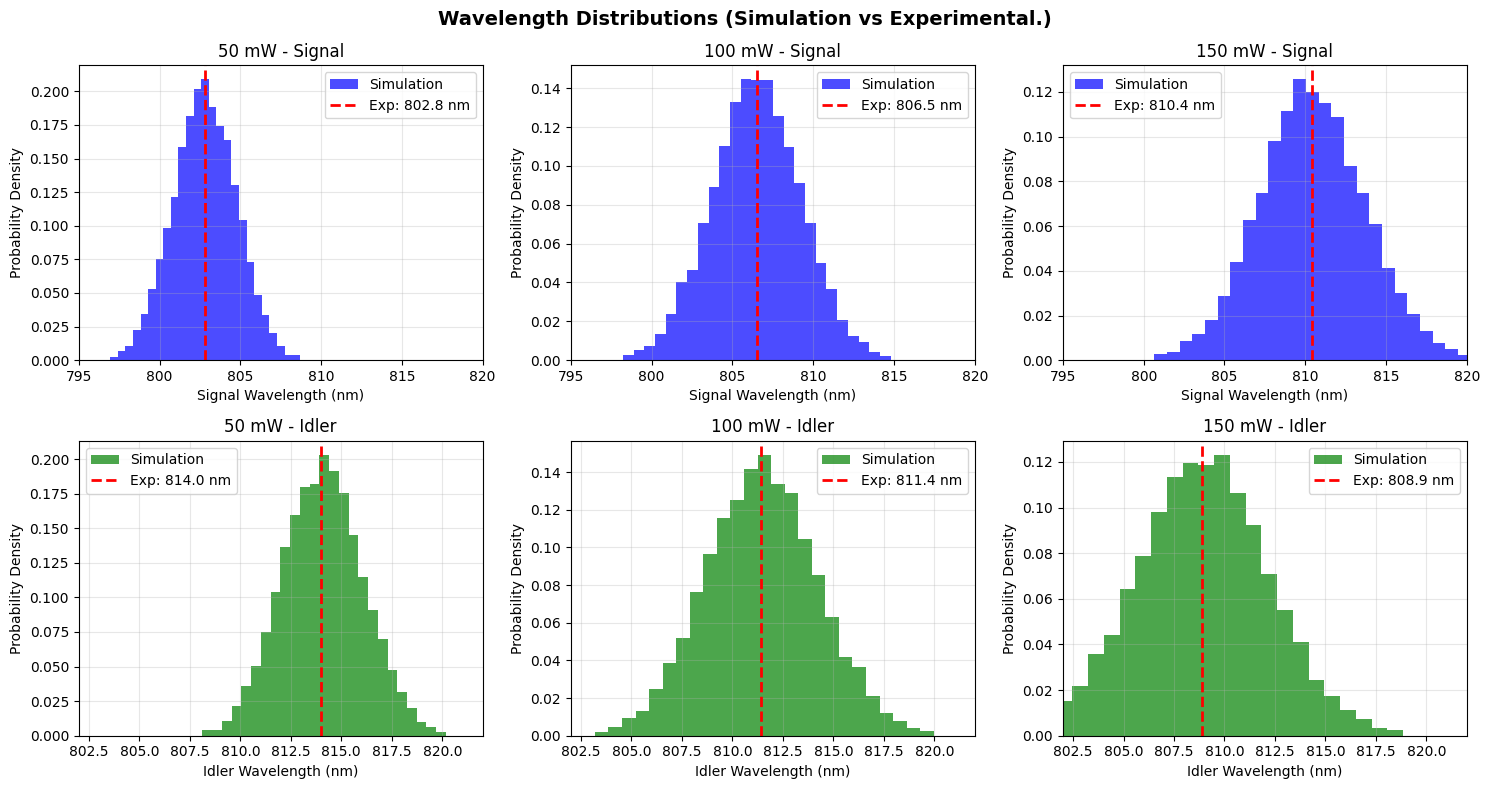

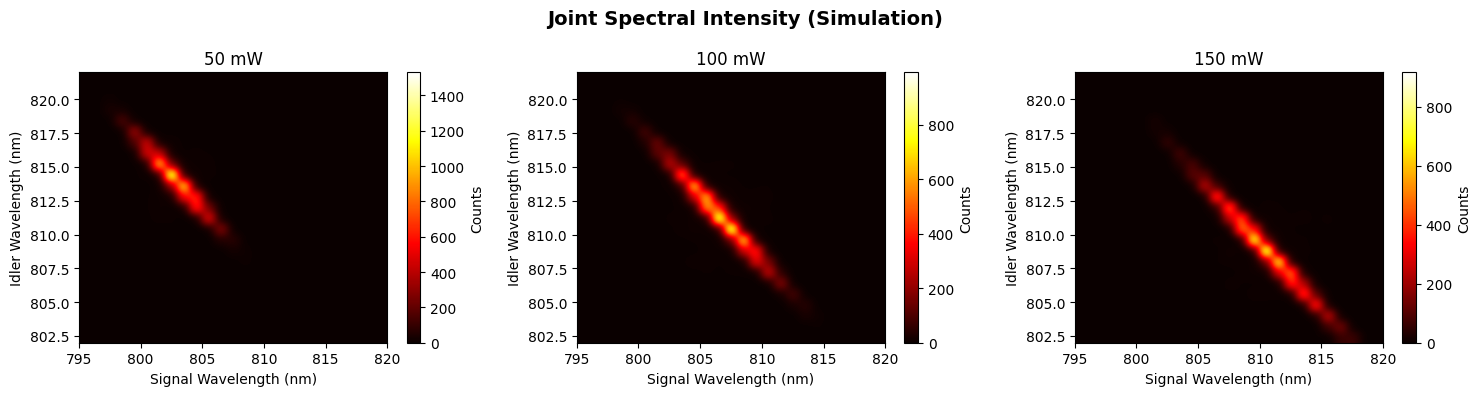

In [ ]:
"""
SPDC Bell Source Validation Against Farella et al. (2024)
==========================================================

This notebook validates the SPDCBellSource implementation against experimental
data from Farella et al., AIP Advances 14, 045034 (2024).

Paper: Characterization of Thorlabs SPDC810 entangled photon source at 
       50, 100, 150 mW pump powers.
"""

import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

from sequence.kernel.timeline import Timeline
from sequence.topology.optical_nodes import SpdcSourceNode
from sequence.components.optical_channel import QuantumChannel
from sequence.utils.encoding import polarization
from sequence.topology.node import Node

# ============================================================================
# Experimental Data from Farella et al. Table I
# ============================================================================

EXPERIMENTAL_DATA = {
    50: {  # 50 mW pump power
        'signal_median': 802.8,  # nm
        'signal_fwhm': 5.9,      # nm
        'idler_median': 814.0,   # nm
        'idler_fwhm': 3.8,       # nm
        'pump_reconstructed': 404.13  # nm
    },
    100: {  # 100 mW pump power
        'signal_median': 806.5,
        'signal_fwhm': 8.3,
        'idler_median': 811.4,
        'idler_fwhm': 5.1,
        'pump_reconstructed': 404.46
    },
    150: {  # 150 mW pump power
        'signal_median': 810.4,
        'signal_fwhm': 9.9,
        'idler_median': 808.9,
        'idler_fwhm': 6.9,
        'pump_reconstructed': 404.80
    }
}

# ============================================================================
# Photon Collector - Captures emitted photons from SPDC source
# ============================================================================

class PhotonCollector(Node):
    """Mock receiver that collects photons without processing them."""

    def __init__(self, name, timeline):
        super().__init__(name, timeline)
        self.photons = []

    def receive_qubit(self, src, photon):
        """Store photon for later analysis."""
        self.photons.append({
            'time': photon.timeline.now(),
            'wavelength': photon.wavelength,
            'name': photon.name
        })

    def get_wavelengths(self):
        """Extract wavelengths from collected photons."""
        return [p['wavelength'] for p in self.photons]

    def clear(self):
        """Reset collector."""
        self.photons = []

# ============================================================================
# Simulation Function
# ============================================================================

def simulate_spdc_source(power_mw, num_pulses=100000):
    """
    Simulate SPDC source at given pump power.

    Args:
        power_mw: Pump power in mW (50, 100, or 150)
        num_pulses: Number of pulses to simulate

    Returns:
        tuple: (signal_wavelengths, idler_wavelengths)
    """
    print(f"\nSimulating {power_mw} mW pump power...")

    # Get experimental parameters for this power
    exp = EXPERIMENTAL_DATA[power_mw]

    # Create timeline
    tl = Timeline()
    tl.seed(42)  # For reproducibility

    # Configure SPDC source
    config = {
        'wavelengths': [exp['signal_median'], exp['idler_median']],
        'frequency': 8e7,  # 80 MHz (typical for pulsed SPDC)
        'mean_photon_num': 0.1,  # Low brightness regime
        'bandwidth': exp['signal_fwhm'],
        'bell_state': 'psi-',
        'encoding': polarization
    }

    # Create source node
    source = SpdcSourceNode("spdc_source", tl, config)

    # Create photon collectors
    signal_collector = PhotonCollector("signal", tl)
    idler_collector = PhotonCollector("idler", tl)

    qc_signal = QuantumChannel("qc_signal", tl, attenuation=0.0, distance=1)  # 1 meter channel
    qc_idler = QuantumChannel("qc_idler", tl, attenuation=0.0, distance=1)  # 1 meter channel

    qc_signal.set_ends(source, signal_collector.name)
    qc_idler.set_ends(source, idler_collector.name)

    # Initialize
    tl.init()

    pairs_per_pulse = []
    period = int(1e12 / config['frequency'])

    # Emit photons
    source.emit(num_pulses=num_pulses)

    # Run simulation
    tl.run()

    # Extract wavelengths
    signal_wavelengths = signal_collector.get_wavelengths()
    idler_wavelengths = idler_collector.get_wavelengths()

    print(f"  Emitted {len(signal_wavelengths)} photon pairs")

    return np.array(signal_wavelengths), np.array(idler_wavelengths)

# ============================================================================
# Analysis Functions
# ============================================================================

def calculate_fwhm(wavelengths):
    """Calculate FWHM from histogram."""
    hist, edges = np.histogram(wavelengths, bins=25, density=True)
    centers = (edges[:-1] + edges[1:]) / 2

    # Find peak
    peak_idx = np.argmax(hist)
    peak_val = hist[peak_idx]
    half_max = peak_val / 2

    # Find width at half maximum
    above_half = hist >= half_max
    indices = np.where(above_half)[0]

    if len(indices) > 1:
        fwhm = centers[indices[-1]] - centers[indices[0]]
    else:
        fwhm = 0

    return fwhm

def analyze_wavelengths(signal, idler):
    """Compute statistics for signal and idler wavelengths."""
    return {
        'signal_median': np.median(signal),
        'signal_fwhm': calculate_fwhm(signal),
        'signal_std': np.std(signal),
        'idler_median': np.median(idler),
        'idler_fwhm': calculate_fwhm(idler),
        'idler_std': np.std(idler)
    }

def reconstruct_pump(signal, idler):
    """Reconstruct pump wavelength from energy conservation."""
    pump_wavelengths = (signal * idler) / (signal + idler)
    return pump_wavelengths

# ============================================================================
# Run Simulations for All Powers
# ============================================================================

print("="*70)
print("SPDC BELL SOURCE VALIDATION")
print("="*70)

results = {}

for power in [50, 100, 150]:
    signal, idler = simulate_spdc_source(power, num_pulses=100000)

    stats = analyze_wavelengths(signal, idler)
    pump = reconstruct_pump(signal, idler)
    stats['pump_reconstructed'] = np.median(pump)

    results[power] = {
        'signal': signal,
        'idler': idler,
        'pump': pump,
        'stats': stats
    }

# ============================================================================
# Figure: Wavelength Distributions
# ============================================================================

print("\nGenerating: Wavelength distributions...")

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Wavelength Distributions (Simulation vs Experimental.)', 
             fontsize=14, fontweight='bold')

signal_xlim = (795, 820)  # Covers all signal wavelengths
idler_xlim = (802, 822)   # Covers all idler wavelengths

for idx, power in enumerate([50, 100, 150]):
    signal = results[power]['signal']
    idler = results[power]['idler']
    exp = EXPERIMENTAL_DATA[power]

    # Signal histogram
    ax_s = axes[0, idx]
    ax_s.hist(signal, bins=25, color='blue', alpha=0.7, density=True, label='Simulation')
    ax_s.axvline(exp['signal_median'], color='red', linestyle='--', 
                 linewidth=2, label=f"Exp: {exp['signal_median']} nm")
    ax_s.set_xlabel('Signal Wavelength (nm)')
    ax_s.set_ylabel('Probability Density')
    ax_s.set_title(f'{power} mW - Signal')
    ax_s.set_xlim(signal_xlim)  
    ax_s.legend()
    ax_s.grid(alpha=0.3)

    # Idler histogram
    ax_i = axes[1, idx]
    ax_i.hist(idler, bins=25, color='green', alpha=0.7, density=True, label='Simulation')
    ax_i.axvline(exp['idler_median'], color='red', linestyle='--', 
                 linewidth=2, label=f"Exp: {exp['idler_median']} nm")
    ax_i.set_xlabel('Idler Wavelength (nm)')
    ax_i.set_ylabel('Probability Density')
    ax_i.set_title(f'{power} mW - Idler')
    ax_i.set_xlim(idler_xlim)
    ax_i.legend()
    ax_i.grid(alpha=0.3)

plt.tight_layout()

# ============================================================================
# Joint Spectral Intensity (JSI)
# ============================================================================

print("\nGenerating: Joint Spectral Intensity...")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Joint Spectral Intensity (Simulation)', 
             fontsize=14, fontweight='bold')

jsi_signal_lim = (795, 820)
jsi_idler_lim = (802, 822)

for idx, power in enumerate([50, 100, 150]):
    signal = results[power]['signal']
    idler = results[power]['idler']

    ax = axes[idx]

    h, xedges, yedges = np.histogram2d(
        signal, idler, 
        bins=25,
        range=[jsi_signal_lim, jsi_idler_lim]
    )

    # Plot as heatmap
    extent = [jsi_signal_lim[0], jsi_signal_lim[1], 
              jsi_idler_lim[0], jsi_idler_lim[1]]
    im = ax.imshow(h.T, origin='lower', extent=extent, aspect='auto', 
                   cmap='hot', interpolation='gaussian')

    ax.set_xlabel('Signal Wavelength (nm)')
    ax.set_ylabel('Idler Wavelength (nm)')
    ax.set_title(f'{power} mW')
    ax.set_xlim(jsi_signal_lim) 
    ax.set_ylim(jsi_idler_lim)  

    plt.colorbar(im, ax=ax, label='Counts')

plt.tight_layout()

# ============================================================================
print("\n" + "="*70)
print("VALIDATION COMPLETE")
print("="*70)

SPDC Source Test Configuration:
  Center wavelengths: lambda_s = 1550.0 nm, lambda_i = 1550.0 nm
  Bandwidth: 2.00 nm
  Sigma (std dev): 0.667 nm
  Generating 10000 pairs...

WAVELENGTH STATISTICS:

Signal photons:
  Mean: 1549.993 nm
  Std:  0.662 nm
  Min:  1548.008 nm
  Max:  1551.971 nm

Idler photons:
  Mean: 1550.007 nm
  Std:  0.662 nm
  Min:  1548.032 nm
  Max:  1551.994 nm

Wavelength difference (Delta_lambda = lambda_signal - lambda_idler):
  Mean: -0.014 nm
  Std:  1.323 nm
  Min:  -3.986 nm
  Max:  3.939 nm

Fraction with |Delta_lambda| < 0.5 nm: 29.3%
Fraction with |Delta_lambda| > 1.5 nm: 26.2%


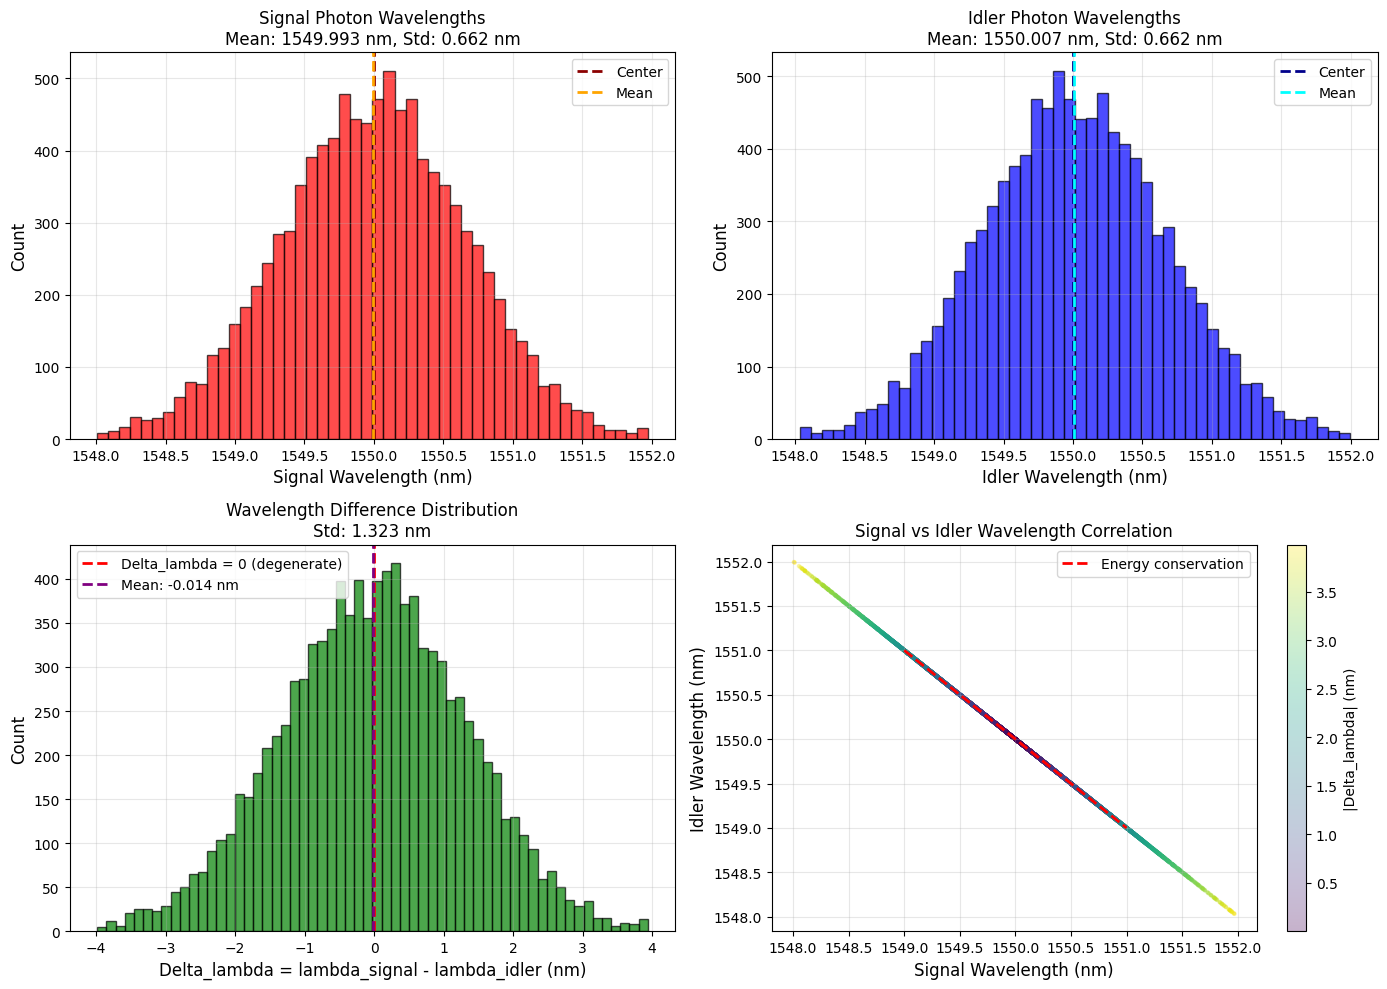


Plot saved as 'spdc_wavelength_distribution_test.png'


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def test_spdc_wavelength_distribution(source, num_samples=10000):
    """
    Test the wavelength distribution of an SPDC source by directly
    sampling the emission process without running the full simulation.
    
    Args:
        source: SPDCBellSource instance
        num_samples: Number of photon pairs to generate
    
    Returns:
        dict with wavelength statistics and creates diagnostic plots
    """
    # Storage for wavelength data
    lambda_signal_list = []
    lambda_idler_list = []
    delta_lambda_list = []
    
    # Extract source parameters
    lambda_signal_center = source.wavelengths[0]
    lambda_idler_center = source.wavelengths[1]
    lam_avg = 0.5 * (lambda_signal_center + lambda_idler_center)
    
    sigma = source.bandwidth / 3.0 if source.bandwidth > 0 else 0.0
    half_bandwidth = source.bandwidth / 2.0
    
    print(f"SPDC Source Test Configuration:")
    print(f"  Center wavelengths: lambda_s = {lambda_signal_center:.1f} nm, lambda_i = {lambda_idler_center:.1f} nm")
    print(f"  Bandwidth: {source.bandwidth:.2f} nm")
    print(f"  Sigma (std dev): {sigma:.3f} nm")
    print(f"  Generating {num_samples} pairs...\n")
    
    # Generate samples using the same logic as emit()
    for i in range(num_samples):
        # Sample signal wavelength
        delta = sigma * source.get_generator().standard_normal()
        while abs(delta) > 3 * sigma:
            delta = sigma * source.get_generator().standard_normal()
        
        lambda_signal = lambda_signal_center + delta
        lambda_idler = lam_avg * lam_avg / lambda_signal
        
        # Store values
        lambda_signal_list.append(lambda_signal)
        lambda_idler_list.append(lambda_idler)
        delta_lambda_list.append(lambda_signal - lambda_idler)
    
    # Convert to numpy arrays
    lambda_signal_arr = np.array(lambda_signal_list)
    lambda_idler_arr = np.array(lambda_idler_list)
    delta_lambda_arr = np.array(delta_lambda_list)
    
    # Compute statistics
    print("=" * 60)
    print("WAVELENGTH STATISTICS:")
    print("=" * 60)
    print(f"\nSignal photons:")
    print(f"  Mean: {np.mean(lambda_signal_arr):.3f} nm")
    print(f"  Std:  {np.std(lambda_signal_arr):.3f} nm")
    print(f"  Min:  {np.min(lambda_signal_arr):.3f} nm")
    print(f"  Max:  {np.max(lambda_signal_arr):.3f} nm")
    
    print(f"\nIdler photons:")
    print(f"  Mean: {np.mean(lambda_idler_arr):.3f} nm")
    print(f"  Std:  {np.std(lambda_idler_arr):.3f} nm")
    print(f"  Min:  {np.min(lambda_idler_arr):.3f} nm")
    print(f"  Max:  {np.max(lambda_idler_arr):.3f} nm")
    
    print(f"\nWavelength difference (Delta_lambda = lambda_signal - lambda_idler):")
    print(f"  Mean: {np.mean(delta_lambda_arr):.3f} nm")
    print(f"  Std:  {np.std(delta_lambda_arr):.3f} nm")
    print(f"  Min:  {np.min(delta_lambda_arr):.3f} nm")
    print(f"  Max:  {np.max(delta_lambda_arr):.3f} nm")
    
    # Count fraction near degeneracy
    frac_near_degenerate = np.sum(np.abs(delta_lambda_arr) < 0.5) / len(delta_lambda_arr) * 100
    print(f"\nFraction with |Delta_lambda| < 0.5 nm: {frac_near_degenerate:.1f}%")
    
    frac_large_delta = np.sum(np.abs(delta_lambda_arr) > 1.5) / len(delta_lambda_arr) * 100
    print(f"Fraction with |Delta_lambda| > 1.5 nm: {frac_large_delta:.1f}%")
    print("=" * 60)
    
    # Create diagnostic plots
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Plot 1: Signal wavelength distribution
    ax = axes[0, 0]
    ax.hist(lambda_signal_arr, bins=50, alpha=0.7, color='red', edgecolor='black')
    ax.axvline(lambda_signal_center, color='darkred', linestyle='--', linewidth=2, label='Center')
    ax.axvline(np.mean(lambda_signal_arr), color='orange', linestyle='--', linewidth=2, label='Mean')
    ax.set_xlabel('Signal Wavelength (nm)', fontsize=12)
    ax.set_ylabel('Count', fontsize=12)
    ax.set_title(f'Signal Photon Wavelengths\nMean: {np.mean(lambda_signal_arr):.3f} nm, Std: {np.std(lambda_signal_arr):.3f} nm', fontsize=12)
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Plot 2: Idler wavelength distribution
    ax = axes[0, 1]
    ax.hist(lambda_idler_arr, bins=50, alpha=0.7, color='blue', edgecolor='black')
    ax.axvline(lambda_idler_center, color='darkblue', linestyle='--', linewidth=2, label='Center')
    ax.axvline(np.mean(lambda_idler_arr), color='cyan', linestyle='--', linewidth=2, label='Mean')
    ax.set_xlabel('Idler Wavelength (nm)', fontsize=12)
    ax.set_ylabel('Count', fontsize=12)
    ax.set_title(f'Idler Photon Wavelengths\nMean: {np.mean(lambda_idler_arr):.3f} nm, Std: {np.std(lambda_idler_arr):.3f} nm', fontsize=12)
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Plot 3: Wavelength difference distribution
    ax = axes[1, 0]
    counts, bins, patches = ax.hist(delta_lambda_arr, bins=60, alpha=0.7, color='green', edgecolor='black')
    ax.axvline(0, color='red', linestyle='--', linewidth=2, label='Delta_lambda = 0 (degenerate)')
    ax.axvline(np.mean(delta_lambda_arr), color='purple', linestyle='--', linewidth=2, label=f'Mean: {np.mean(delta_lambda_arr):.3f} nm')
    ax.set_xlabel('Delta_lambda = lambda_signal - lambda_idler (nm)', fontsize=12)
    ax.set_ylabel('Count', fontsize=12)
    ax.set_title(f'Wavelength Difference Distribution\nStd: {np.std(delta_lambda_arr):.3f} nm', fontsize=12)
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Plot 4: Correlation plot
    ax = axes[1, 1]
    scatter = ax.scatter(lambda_signal_arr, lambda_idler_arr, alpha=0.3, s=5, c=np.abs(delta_lambda_arr), cmap='viridis')
    ax.plot([lambda_signal_center-1, lambda_signal_center+1], 
            [lambda_idler_center+1, lambda_idler_center-1], 
            'r--', linewidth=2, label='Energy conservation')
    ax.set_xlabel('Signal Wavelength (nm)', fontsize=12)
    ax.set_ylabel('Idler Wavelength (nm)', fontsize=12)
    ax.set_title('Signal vs Idler Wavelength Correlation', fontsize=12)
    ax.legend()
    ax.grid(True, alpha=0.3)
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label('|Delta_lambda| (nm)', fontsize=10)
    
    plt.tight_layout()
    plt.show()
        
    # Return statistics dictionary
    return {
        'lambda_signal': lambda_signal_arr,
        'lambda_idler': lambda_idler_arr,
        'delta_lambda': delta_lambda_arr,
        'frac_near_degenerate': frac_near_degenerate,
        'frac_large_delta': frac_large_delta
    }

from sequence.components.light_source import SPDCBellSource
from sequence.kernel.timeline import Timeline
tl = Timeline()
source = SPDCBellSource(
    name="test_spdc",
    timeline=tl,
    wavelengths=[1550, 1550],
    bandwidth=2.0,  # 2 nm bandwidth
    bell_state="psi-"
)

# 2. Run the wavelength distribution test BEFORE running the simulation
stats = test_spdc_wavelength_distribution(source, num_samples=10000)